# Logistic Regression vs Linear Regression - Visual Comparison
### Understanding When to Use Which Regression

**The Confusion:**
- Both have "regression" in the name
- But used for completely different problems!
- Linear Regression → Predict numbers (continuous)
- Logistic Regression → Classify categories (discrete)

**Key Difference:**
```
Linear:   y = mx + b           (straight line)
Logistic: y = 1/(1 + e^(-z))   (S-curve sigmoid)
```

**What You'll Learn:**
1. Linear Regression - Predicting continuous values
2. Logistic Regression - Classifying binary outcomes
3. Why linear regression fails for classification
4. Decision boundaries and probabilities
5. When to use which

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix
from sklearn.datasets import make_classification

plt.style.use('seaborn-v0_8')
np.random.seed(42)

print("📊 Logistic vs Linear Regression - Visual Comparison")
print("="*70)

📊 Logistic vs Linear Regression - Visual Comparison


## 1. Linear Regression - Predicting Continuous Values


SECTION 1: LINEAR REGRESSION - CONTINUOUS OUTPUT


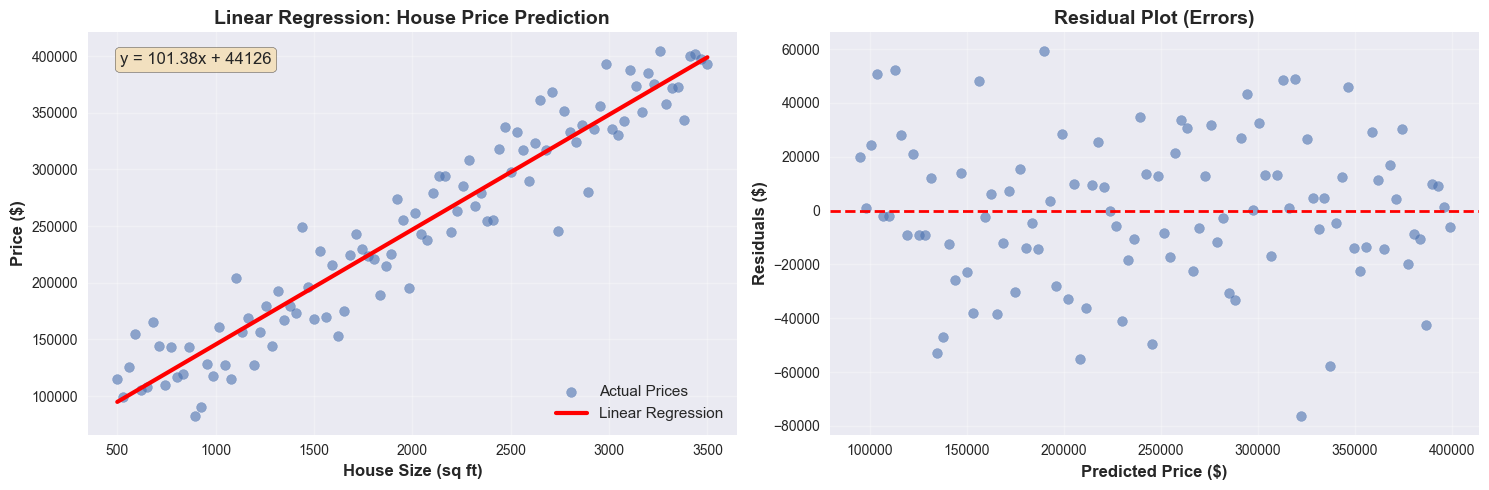


📈 LINEAR REGRESSION CHARACTERISTICS:
   • Output: Continuous values (any real number)
   • Formula: y = 101.38x + 44126
   • Range: (-∞, +∞) - unbounded
   • Loss Function: Mean Squared Error (MSE)
   • R² Score: 0.9147 (1.0 = perfect fit)
   • RMSE: $27,082

🎯 USE CASES:
   ✓ Predicting house prices
   ✓ Sales forecasting
   ✓ Temperature prediction
   ✓ Stock prices
   ✓ ANY continuous numerical output


In [2]:
print("\nSECTION 1: LINEAR REGRESSION - CONTINUOUS OUTPUT")
print("="*70)

# Generate data: House prices based on size
np.random.seed(42)
house_size = np.linspace(500, 3500, 100)  # Square feet
house_price = 50000 + 100 * house_size + np.random.normal(0, 30000, 100)  # Price with noise

# Reshape for sklearn
X_house = house_size.reshape(-1, 1)
y_house = house_price

# Fit linear regression
lr_model = LinearRegression()
lr_model.fit(X_house, y_house)
y_pred_linear = lr_model.predict(X_house)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Data and regression line
axes[0].scatter(house_size, house_price, alpha=0.6, s=50, label='Actual Prices')
axes[0].plot(house_size, y_pred_linear, 'r-', linewidth=3, label='Linear Regression')
axes[0].set_xlabel('House Size (sq ft)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=12, fontweight='bold')
axes[0].set_title('Linear Regression: House Price Prediction', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Add equation
slope = lr_model.coef_[0]
intercept = lr_model.intercept_
axes[0].text(0.05, 0.95, f'y = {slope:.2f}x + {intercept:.0f}',
            transform=axes[0].transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Residuals
residuals = y_house - y_pred_linear
axes[1].scatter(y_pred_linear, residuals, alpha=0.6, s=50)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Residuals ($)', fontsize=12, fontweight='bold')
axes[1].set_title('Residual Plot (Errors)', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Metrics
mse = mean_squared_error(y_house, y_pred_linear)
rmse = np.sqrt(mse)
r2 = lr_model.score(X_house, y_house)

print("\n📈 LINEAR REGRESSION CHARACTERISTICS:")
print(f"   • Output: Continuous values (any real number)")
print(f"   • Formula: y = {slope:.2f}x + {intercept:.0f}")
print(f"   • Range: (-∞, +∞) - unbounded")
print(f"   • Loss Function: Mean Squared Error (MSE)")
print(f"   • R² Score: {r2:.4f} (1.0 = perfect fit)")
print(f"   • RMSE: ${rmse:,.0f}")

print("\n🎯 USE CASES:")
print("   ✓ Predicting house prices")
print("   ✓ Sales forecasting")
print("   ✓ Temperature prediction")
print("   ✓ Stock prices")
print("   ✓ ANY continuous numerical output")
print("="*70)

## 2. Logistic Regression - Classifying Binary Outcomes


SECTION 2: LOGISTIC REGRESSION - BINARY CLASSIFICATION


/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


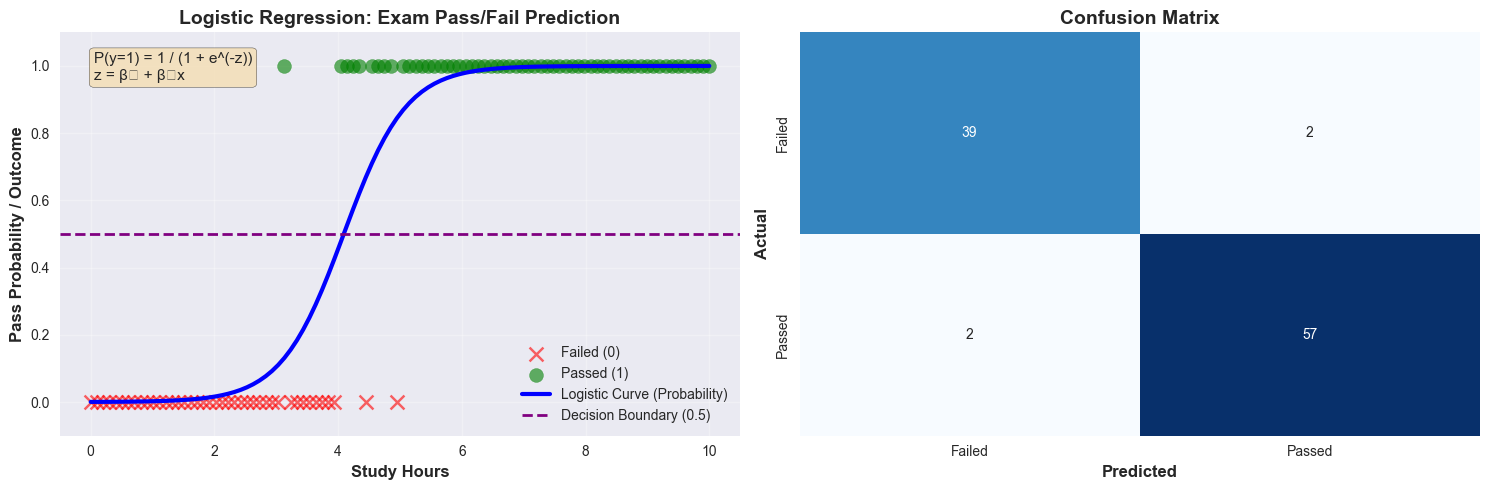


📈 LOGISTIC REGRESSION CHARACTERISTICS:
   • Output: Probabilities [0, 1] → Classes (0 or 1)
   • Formula: P(y=1) = 1 / (1 + e^(-z)), z = β₀ + β₁x
   • Range: [0, 1] - bounded by sigmoid function
   • Loss Function: Log Loss (Binary Cross-Entropy)
   • Accuracy: 0.9600 (96.00%)
   • Decision Threshold: 0.5 (probability > 0.5 → class 1)

🎯 USE CASES:
   ✓ Email spam detection (spam/not spam)
   ✓ Disease diagnosis (positive/negative)
   ✓ Customer churn (churn/stay)
   ✓ Fraud detection (fraud/legitimate)
   ✓ ANY binary classification problem


In [3]:
print("\nSECTION 2: LOGISTIC REGRESSION - BINARY CLASSIFICATION")
print("="*70)

# Generate data: Exam pass/fail based on study hours
np.random.seed(42)
study_hours = np.linspace(0, 10, 100)

# Create probability using sigmoid-like relationship
z = -5 + 1.2 * study_hours
prob_pass = 1 / (1 + np.exp(-z))

# Generate binary outcomes with some randomness
exam_result = (prob_pass + np.random.normal(0, 0.15, 100)) > 0.5
exam_result = exam_result.astype(int)

# Reshape for sklearn
X_exam = study_hours.reshape(-1, 1)
y_exam = exam_result

# Fit logistic regression
log_model = LogisticRegression()
log_model.fit(X_exam, y_exam)
y_pred_proba = log_model.predict_proba(X_exam)[:, 1]  # Probability of class 1
y_pred_class = log_model.predict(X_exam)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Logistic curve with data points
axes[0].scatter(study_hours[y_exam == 0], y_exam[y_exam == 0], 
               color='red', s=100, alpha=0.6, label='Failed (0)', marker='x')
axes[0].scatter(study_hours[y_exam == 1], y_exam[y_exam == 1], 
               color='green', s=100, alpha=0.6, label='Passed (1)', marker='o')
axes[0].plot(study_hours, y_pred_proba, 'b-', linewidth=3, label='Logistic Curve (Probability)')
axes[0].axhline(y=0.5, color='purple', linestyle='--', linewidth=2, label='Decision Boundary (0.5)')
axes[0].set_xlabel('Study Hours', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Pass Probability / Outcome', fontsize=12, fontweight='bold')
axes[0].set_title('Logistic Regression: Exam Pass/Fail Prediction', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_ylim([-0.1, 1.1])

# Add sigmoid equation
axes[0].text(0.05, 0.95, 'P(y=1) = 1 / (1 + e^(-z))\nz = β₀ + β₁x',
            transform=axes[0].transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_exam, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
           xticklabels=['Failed', 'Passed'], yticklabels=['Failed', 'Passed'])
axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[1].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Metrics
accuracy = accuracy_score(y_exam, y_pred_class)

print("\n📈 LOGISTIC REGRESSION CHARACTERISTICS:")
print(f"   • Output: Probabilities [0, 1] → Classes (0 or 1)")
print(f"   • Formula: P(y=1) = 1 / (1 + e^(-z)), z = β₀ + β₁x")
print(f"   • Range: [0, 1] - bounded by sigmoid function")
print(f"   • Loss Function: Log Loss (Binary Cross-Entropy)")
print(f"   • Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   • Decision Threshold: 0.5 (probability > 0.5 → class 1)")

print("\n🎯 USE CASES:")
print("   ✓ Email spam detection (spam/not spam)")
print("   ✓ Disease diagnosis (positive/negative)")
print("   ✓ Customer churn (churn/stay)")
print("   ✓ Fraud detection (fraud/legitimate)")
print("   ✓ ANY binary classification problem")
print("="*70)

## 3. Why Linear Regression Fails for Classification


SECTION 3: WHY LINEAR REGRESSION FAILS FOR CLASSIFICATION


/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_18477/2960040856.py:78: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_18477/2960040856.py:78: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_18477/2960040856.py:78: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Aria

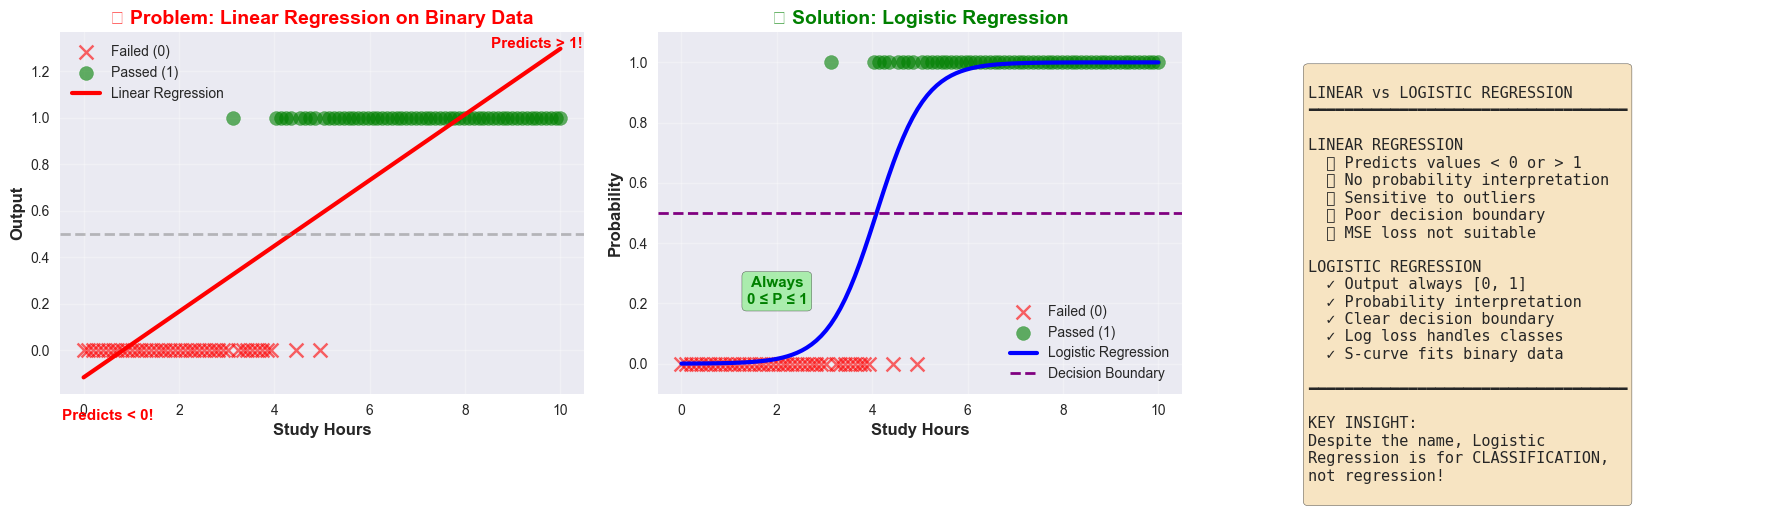


🚨 PROBLEMS WITH LINEAR REGRESSION FOR CLASSIFICATION:

   1. UNBOUNDED OUTPUT:
      • Min prediction: -0.1154 (< 0!)
      • Max prediction: 1.2954 (> 1!)
      • Can't interpret as probability

   2. NO NATURAL THRESHOLD:
      • Where to cut? 0.5? 0.6? 0.4?
      • Arbitrary and dataset-dependent

   3. SENSITIVE TO OUTLIERS:
      • One extreme point shifts entire line
      • Poor generalization

   4. WRONG LOSS FUNCTION:
      • MSE penalizes correct predictions far from 0/1
      • Log loss better for probabilities

✓ LOGISTIC REGRESSION SOLVES ALL THESE:
   • Sigmoid function bounds output [0, 1]
   • Natural probability interpretation
   • Clear decision boundary at P=0.5
   • Log loss optimized for classification


In [4]:
print("\nSECTION 3: WHY LINEAR REGRESSION FAILS FOR CLASSIFICATION")
print("="*70)

# Fit linear regression on classification data (WRONG!)
lr_on_classification = LinearRegression()
lr_on_classification.fit(X_exam, y_exam)
y_pred_linear_class = lr_on_classification.predict(X_exam)

# Visualize the problem
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Linear regression on binary data
axes[0].scatter(study_hours[y_exam == 0], y_exam[y_exam == 0], 
               color='red', s=100, alpha=0.6, label='Failed (0)', marker='x')
axes[0].scatter(study_hours[y_exam == 1], y_exam[y_exam == 1], 
               color='green', s=100, alpha=0.6, label='Passed (1)', marker='o')
axes[0].plot(study_hours, y_pred_linear_class, 'r-', linewidth=3, label='Linear Regression')
axes[0].axhline(y=0.5, color='gray', linestyle='--', linewidth=2, alpha=0.5)
axes[0].set_xlabel('Study Hours', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Output', fontsize=12, fontweight='bold')
axes[0].set_title('❌ Problem: Linear Regression on Binary Data', fontsize=14, fontweight='bold', color='red')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Highlight problems
axes[0].text(0.5, -0.3, 'Predicts < 0!', ha='center', fontsize=11, color='red', fontweight='bold')
axes[0].text(9.5, 1.3, 'Predicts > 1!', ha='center', fontsize=11, color='red', fontweight='bold')

# Plot 2: Logistic regression (correct)
axes[1].scatter(study_hours[y_exam == 0], y_exam[y_exam == 0], 
               color='red', s=100, alpha=0.6, label='Failed (0)', marker='x')
axes[1].scatter(study_hours[y_exam == 1], y_exam[y_exam == 1], 
               color='green', s=100, alpha=0.6, label='Passed (1)', marker='o')
axes[1].plot(study_hours, y_pred_proba, 'b-', linewidth=3, label='Logistic Regression')
axes[1].axhline(y=0.5, color='purple', linestyle='--', linewidth=2, label='Decision Boundary')
axes[1].set_xlabel('Study Hours', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Probability', fontsize=12, fontweight='bold')
axes[1].set_title('✓ Solution: Logistic Regression', fontsize=14, fontweight='bold', color='green')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim([-0.1, 1.1])

# Add annotations
axes[1].text(2, 0.2, 'Always\n0 ≤ P ≤ 1', ha='center', fontsize=11, color='green', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Plot 3: Comparison table
axes[2].axis('off')
comparison_text = """
LINEAR vs LOGISTIC REGRESSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

LINEAR REGRESSION
  ❌ Predicts values < 0 or > 1
  ❌ No probability interpretation
  ❌ Sensitive to outliers
  ❌ Poor decision boundary
  ❌ MSE loss not suitable

LOGISTIC REGRESSION
  ✓ Output always [0, 1]
  ✓ Probability interpretation
  ✓ Clear decision boundary
  ✓ Log loss handles classes
  ✓ S-curve fits binary data

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

KEY INSIGHT:
Despite the name, Logistic
Regression is for CLASSIFICATION,
not regression!
"""
axes[2].text(0.1, 0.9, comparison_text, fontsize=11, family='monospace',
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n🚨 PROBLEMS WITH LINEAR REGRESSION FOR CLASSIFICATION:")
print("")
print("   1. UNBOUNDED OUTPUT:")
print(f"      • Min prediction: {y_pred_linear_class.min():.4f} (< 0!)")
print(f"      • Max prediction: {y_pred_linear_class.max():.4f} (> 1!)")
print("      • Can't interpret as probability")

print("\n   2. NO NATURAL THRESHOLD:")
print("      • Where to cut? 0.5? 0.6? 0.4?")
print("      • Arbitrary and dataset-dependent")

print("\n   3. SENSITIVE TO OUTLIERS:")
print("      • One extreme point shifts entire line")
print("      • Poor generalization")

print("\n   4. WRONG LOSS FUNCTION:")
print("      • MSE penalizes correct predictions far from 0/1")
print("      • Log loss better for probabilities")

print("\n✓ LOGISTIC REGRESSION SOLVES ALL THESE:")
print("   • Sigmoid function bounds output [0, 1]")
print("   • Natural probability interpretation")
print("   • Clear decision boundary at P=0.5")
print("   • Log loss optimized for classification")
print("="*70)

## 4. The Sigmoid Function - Heart of Logistic Regression


SECTION 4: THE SIGMOID FUNCTION


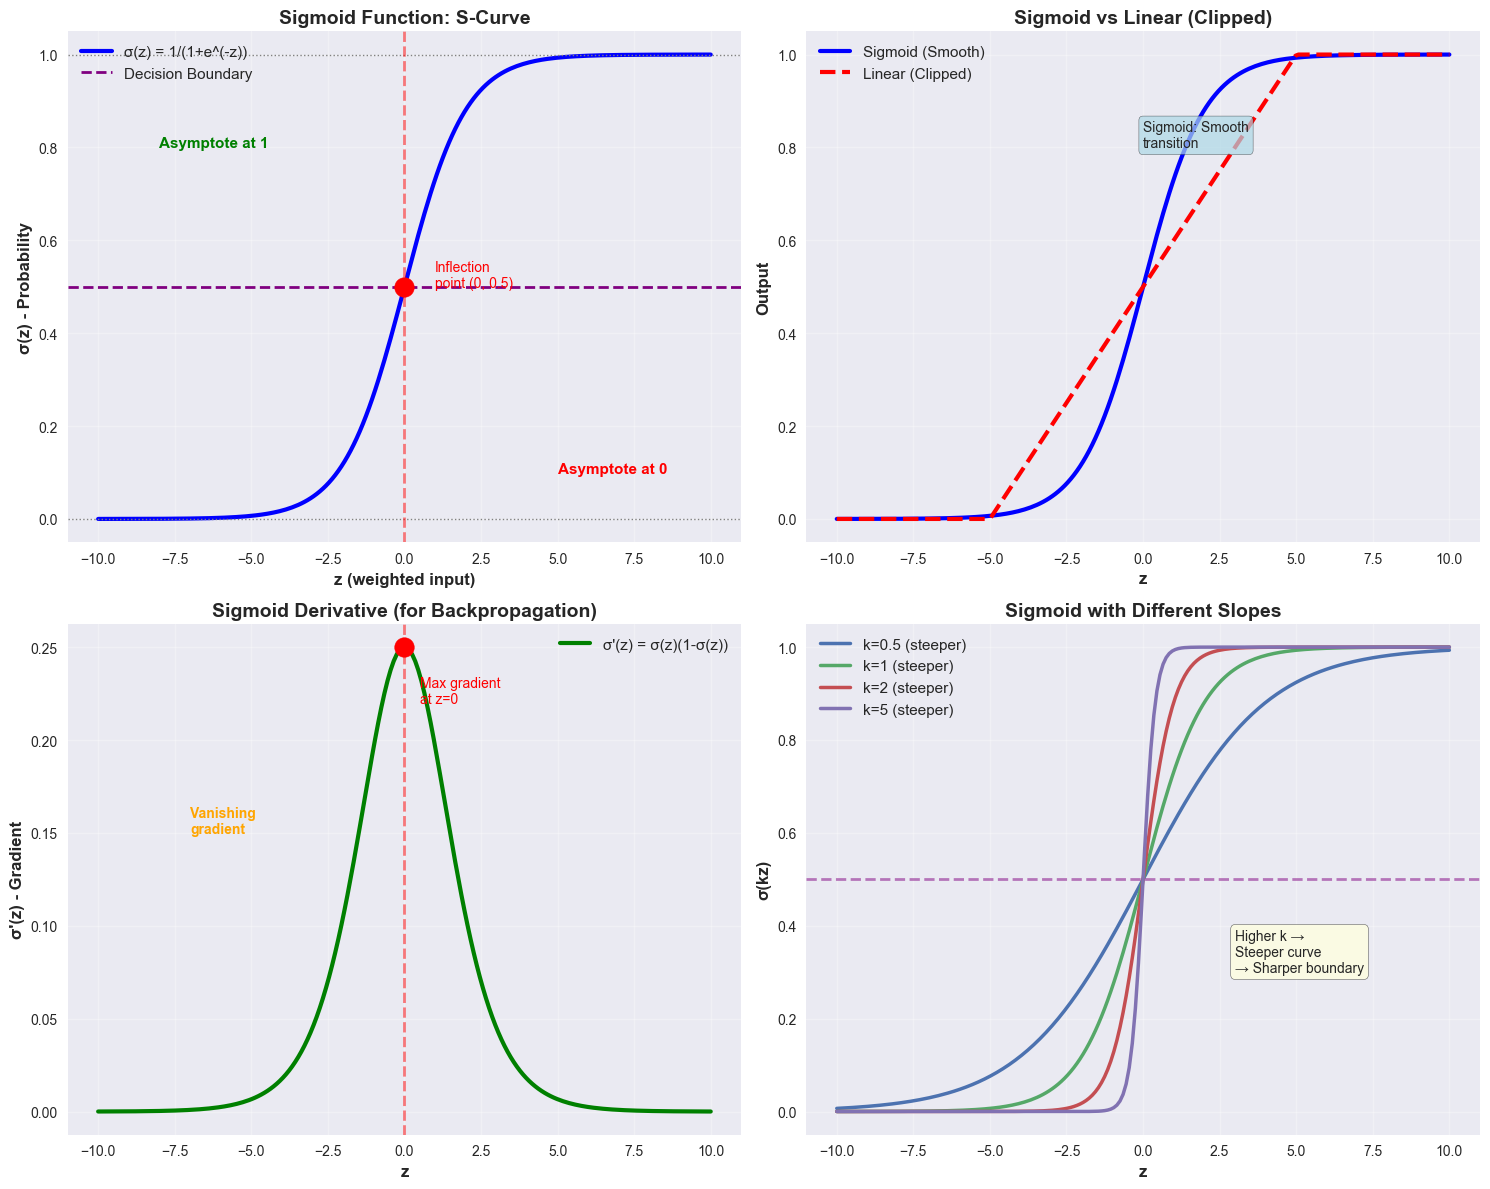


🔬 SIGMOID FUNCTION PROPERTIES:

   MATHEMATICAL FORM:
      σ(z) = 1 / (1 + e^(-z))
      where z = β₀ + β₁x₁ + β₂x₂ + ... (weighted sum)

   KEY PROPERTIES:
      1. Range: [0, 1] - perfect for probabilities
      2. S-shaped curve - smooth transition
      3. Inflection point: (0, 0.5)
      4. Asymptotes: 0 (z→-∞) and 1 (z→+∞)
      5. Symmetric around z=0

   DERIVATIVE (for gradient descent):
      σ'(z) = σ(z) × (1 - σ(z))
      • Maximum at z=0: σ'(0) = 0.25
      • Vanishes at extremes (|z| > 5)

   INTERPRETATION:
      z > 0  → P(y=1) > 0.5 → Predict class 1
      z = 0  → P(y=1) = 0.5 → Decision boundary
      z < 0  → P(y=1) < 0.5 → Predict class 0

💡 WHY SIGMOID?
   • Maps any real number to probability [0, 1]
   • Differentiable everywhere (gradient descent works)
   • Nice derivative: σ'(z) = σ(z)(1-σ(z)) - easy to compute!
   • Historically from logistic growth model (1838)


In [5]:
print("\nSECTION 4: THE SIGMOID FUNCTION")
print("="*70)

# Define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate z values
z = np.linspace(-10, 10, 200)
sigmoid_values = sigmoid(z)

# Visualize sigmoid properties
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Sigmoid function
axes[0, 0].plot(z, sigmoid_values, 'b-', linewidth=3, label='σ(z) = 1/(1+e^(-z))')
axes[0, 0].axhline(y=0.5, color='purple', linestyle='--', linewidth=2, label='Decision Boundary')
axes[0, 0].axhline(y=0, color='gray', linestyle=':', linewidth=1)
axes[0, 0].axhline(y=1, color='gray', linestyle=':', linewidth=1)
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[0, 0].scatter([0], [0.5], color='red', s=200, zorder=5)
axes[0, 0].set_xlabel('z (weighted input)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('σ(z) - Probability', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Sigmoid Function: S-Curve', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(alpha=0.3)
axes[0, 0].text(-8, 0.8, 'Asymptote at 1', fontsize=11, color='green', fontweight='bold')
axes[0, 0].text(5, 0.1, 'Asymptote at 0', fontsize=11, color='red', fontweight='bold')
axes[0, 0].text(1, 0.5, 'Inflection\npoint (0, 0.5)', fontsize=10, color='red')

# Plot 2: Compare sigmoid vs linear
linear_values = np.clip(0.1 * z + 0.5, 0, 1)  # Clipped linear
axes[0, 1].plot(z, sigmoid_values, 'b-', linewidth=3, label='Sigmoid (Smooth)')
axes[0, 1].plot(z, linear_values, 'r--', linewidth=3, label='Linear (Clipped)')
axes[0, 1].set_xlabel('z', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Output', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Sigmoid vs Linear (Clipped)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].text(0, 0.8, 'Sigmoid: Smooth\ntransition', fontsize=10, 
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Plot 3: Sigmoid gradient (derivative)
sigmoid_gradient = sigmoid_values * (1 - sigmoid_values)
axes[1, 0].plot(z, sigmoid_gradient, 'g-', linewidth=3, label="σ'(z) = σ(z)(1-σ(z))")
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[1, 0].scatter([0], [0.25], color='red', s=200, zorder=5)
axes[1, 0].set_xlabel('z', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("σ'(z) - Gradient", fontsize=12, fontweight='bold')
axes[1, 0].set_title('Sigmoid Derivative (for Backpropagation)', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(alpha=0.3)
axes[1, 0].text(0.5, 0.22, 'Max gradient\nat z=0', fontsize=10, color='red')
axes[1, 0].text(-7, 0.15, 'Vanishing\ngradient', fontsize=10, color='orange', fontweight='bold')

# Plot 4: Different sigmoid steepness
for k in [0.5, 1, 2, 5]:
    axes[1, 1].plot(z, sigmoid(k * z), linewidth=2.5, label=f'k={k} (steeper)')
axes[1, 1].axhline(y=0.5, color='purple', linestyle='--', linewidth=2, alpha=0.5)
axes[1, 1].set_xlabel('z', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('σ(kz)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Sigmoid with Different Slopes', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].text(3, 0.3, 'Higher k →\nSteeper curve\n→ Sharper boundary', fontsize=10,
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n🔬 SIGMOID FUNCTION PROPERTIES:")
print("")
print("   MATHEMATICAL FORM:")
print("      σ(z) = 1 / (1 + e^(-z))")
print("      where z = β₀ + β₁x₁ + β₂x₂ + ... (weighted sum)")
print("")
print("   KEY PROPERTIES:")
print("      1. Range: [0, 1] - perfect for probabilities")
print("      2. S-shaped curve - smooth transition")
print("      3. Inflection point: (0, 0.5)")
print("      4. Asymptotes: 0 (z→-∞) and 1 (z→+∞)")
print("      5. Symmetric around z=0")
print("")
print("   DERIVATIVE (for gradient descent):")
print("      σ'(z) = σ(z) × (1 - σ(z))")
print("      • Maximum at z=0: σ'(0) = 0.25")
print("      • Vanishes at extremes (|z| > 5)")
print("")
print("   INTERPRETATION:")
print("      z > 0  → P(y=1) > 0.5 → Predict class 1")
print("      z = 0  → P(y=1) = 0.5 → Decision boundary")
print("      z < 0  → P(y=1) < 0.5 → Predict class 0")

print("\n💡 WHY SIGMOID?")
print("   • Maps any real number to probability [0, 1]")
print("   • Differentiable everywhere (gradient descent works)")
print("   • Nice derivative: σ'(z) = σ(z)(1-σ(z)) - easy to compute!")
print("   • Historically from logistic growth model (1838)")
print("="*70)

## 5. Decision Boundaries - 2D Visualization


SECTION 5: DECISION BOUNDARIES IN 2D


/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_18477/1466794244.py:68: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_18477/1466794244.py:68: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


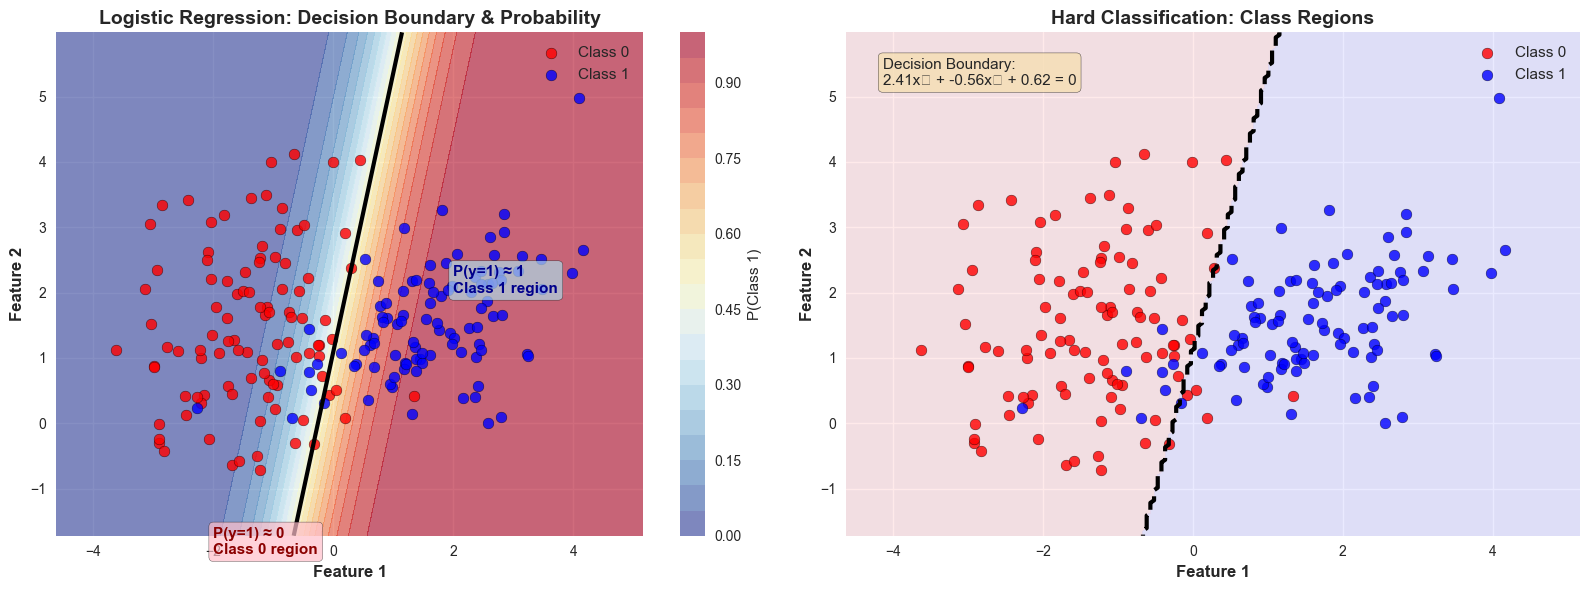


🎯 DECISION BOUNDARY EXPLAINED:

   DEFINITION:
      The line/plane where P(y=1) = 0.5
      Equation: 2.41x₁ + -0.56x₂ + 0.62 = 0

   IN 2D: Decision boundary is a LINE
      • Points above line: P(y=1) > 0.5 → Class 1
      • Points below line: P(y=1) < 0.5 → Class 0
      • Points on line: P(y=1) = 0.5 (uncertain)

   IN 3D: Decision boundary is a PLANE
   IN N-D: Decision boundary is a HYPERPLANE

   KEY INSIGHT:
      Logistic regression creates LINEAR decision boundary
      → Can only separate linearly separable data
      → For non-linear: Use polynomial features or neural networks

   Accuracy: 0.9400 (94.00%)


In [6]:
print("\nSECTION 5: DECISION BOUNDARIES IN 2D")
print("="*70)

# Generate 2D classification data
np.random.seed(42)
X_2d, y_2d = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                                 n_informative=2, n_clusters_per_class=1,
                                 class_sep=1.5, random_state=42)

# Fit logistic regression
log_2d = LogisticRegression()
log_2d.fit(X_2d, y_2d)

# Create mesh for decision boundary
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict probabilities on mesh
Z = log_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Decision boundary with probability contours
contour = axes[0].contourf(xx, yy, Z, levels=20, cmap='RdYlBu_r', alpha=0.6)
axes[0].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=3)
axes[0].scatter(X_2d[y_2d == 0, 0], X_2d[y_2d == 0, 1], 
               c='red', s=60, alpha=0.8, edgecolors='black', label='Class 0')
axes[0].scatter(X_2d[y_2d == 1, 0], X_2d[y_2d == 1, 1], 
               c='blue', s=60, alpha=0.8, edgecolors='black', label='Class 1')
axes[0].set_xlabel('Feature 1', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Feature 2', fontsize=12, fontweight='bold')
axes[0].set_title('Logistic Regression: Decision Boundary & Probability', 
                 fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
plt.colorbar(contour, ax=axes[0], label='P(Class 1)')

# Add annotations
axes[0].text(-2, -2, 'P(y=1) ≈ 0\nClass 0 region', fontsize=11, color='darkred', 
            fontweight='bold', bbox=dict(boxstyle='round', facecolor='pink', alpha=0.7))
axes[0].text(2, 2, 'P(y=1) ≈ 1\nClass 1 region', fontsize=11, color='darkblue',
            fontweight='bold', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Plot 2: Hard classification (0 or 1)
Z_class = log_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_class = Z_class.reshape(xx.shape)
axes[1].contourf(xx, yy, Z_class, levels=1, colors=['#ffcccc', '#ccccff'], alpha=0.4)
axes[1].contour(xx, yy, Z_class, levels=[0.5], colors='black', linewidths=3, linestyles='--')
axes[1].scatter(X_2d[y_2d == 0, 0], X_2d[y_2d == 0, 1], 
               c='red', s=60, alpha=0.8, edgecolors='black', label='Class 0')
axes[1].scatter(X_2d[y_2d == 1, 0], X_2d[y_2d == 1, 1], 
               c='blue', s=60, alpha=0.8, edgecolors='black', label='Class 1')
axes[1].set_xlabel('Feature 1', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Feature 2', fontsize=12, fontweight='bold')
axes[1].set_title('Hard Classification: Class Regions', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

# Decision boundary equation
coef = log_2d.coef_[0]
intercept = log_2d.intercept_[0]
axes[1].text(0.05, 0.95, f'Decision Boundary:\n{coef[0]:.2f}x₁ + {coef[1]:.2f}x₂ + {intercept:.2f} = 0',
            transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n🎯 DECISION BOUNDARY EXPLAINED:")
print("")
print("   DEFINITION:")
print("      The line/plane where P(y=1) = 0.5")
print(f"      Equation: {coef[0]:.2f}x₁ + {coef[1]:.2f}x₂ + {intercept:.2f} = 0")
print("")
print("   IN 2D: Decision boundary is a LINE")
print("      • Points above line: P(y=1) > 0.5 → Class 1")
print("      • Points below line: P(y=1) < 0.5 → Class 0")
print("      • Points on line: P(y=1) = 0.5 (uncertain)")
print("")
print("   IN 3D: Decision boundary is a PLANE")
print("   IN N-D: Decision boundary is a HYPERPLANE")
print("")
print("   KEY INSIGHT:")
print("      Logistic regression creates LINEAR decision boundary")
print("      → Can only separate linearly separable data")
print("      → For non-linear: Use polynomial features or neural networks")

# Calculate accuracy
y_pred_2d = log_2d.predict(X_2d)
acc_2d = accuracy_score(y_2d, y_pred_2d)
print(f"\n   Accuracy: {acc_2d:.4f} ({acc_2d*100:.2f}%)")
print("="*70)

## 6. Loss Functions: MSE vs Log Loss


SECTION 6: LOSS FUNCTIONS - MSE vs LOG LOSS


/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_18477/2376313127.py:112: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


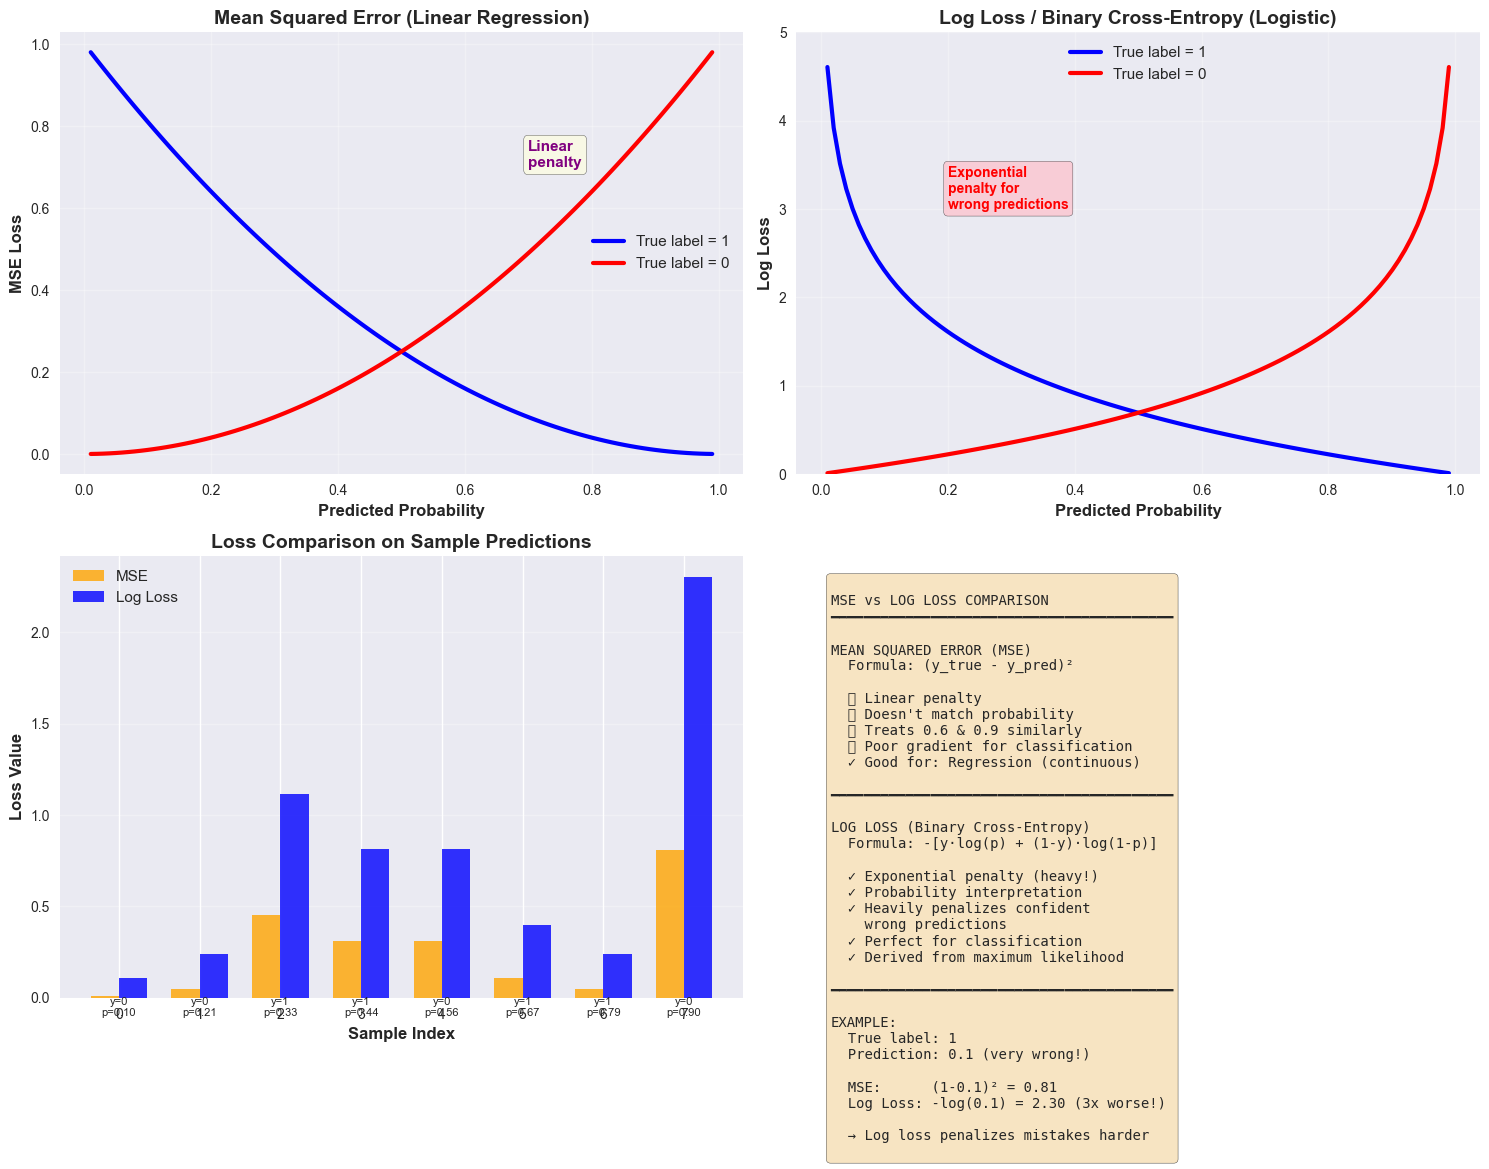


📐 LOSS FUNCTION FORMULAS:

   MEAN SQUARED ERROR (Linear Regression):
      MSE = (1/n) Σ(y_true - y_pred)²
      • Penalty: Linear (quadratic)
      • Range: [0, ∞)
      • Good for: Continuous predictions

   LOG LOSS / Binary Cross-Entropy (Logistic):
      Log Loss = -(1/n) Σ[y·log(p) + (1-y)·log(1-p)]
      where p = predicted probability
      • Penalty: Exponential (harsh on mistakes)
      • Range: [0, ∞)
      • Good for: Probability predictions

   WHY LOG LOSS FOR CLASSIFICATION?
      1. Derived from Maximum Likelihood Estimation
      2. Heavily penalizes confident wrong predictions
      3. Matches probabilistic interpretation
      4. Convex (guaranteed global minimum)
      5. Works well with gradient descent

🔢 NUMERICAL EXAMPLE:
   Scenario: True label = 1, Prediction = 0.1 (very wrong!)
   MSE Loss:  0.8100
   Log Loss:  2.3026
   Ratio:     2.84x (log loss penalizes 2.84x more!)

   Scenario: True label = 1, Prediction = 0.9 (good!)
   MSE Loss:  0.0100
   Log Loss

In [7]:
print("\nSECTION 6: LOSS FUNCTIONS - MSE vs LOG LOSS")
print("="*70)

# Generate predictions and true labels
y_true = np.array([0, 0, 1, 1, 0, 1, 1, 0])
y_pred_probs = np.linspace(0.1, 0.9, 8)

# Calculate losses
def mean_squared_error_manual(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def log_loss_manual(y_true, y_pred):
    epsilon = 1e-15  # Avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Visualize loss functions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: MSE loss curve
probs = np.linspace(0.01, 0.99, 100)
mse_y1 = (1 - probs) ** 2  # Loss when true label = 1
mse_y0 = (0 - probs) ** 2  # Loss when true label = 0

axes[0, 0].plot(probs, mse_y1, 'b-', linewidth=3, label='True label = 1')
axes[0, 0].plot(probs, mse_y0, 'r-', linewidth=3, label='True label = 0')
axes[0, 0].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('MSE Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Mean Squared Error (Linear Regression)', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(alpha=0.3)
axes[0, 0].text(0.7, 0.7, 'Linear\npenalty', fontsize=11, color='purple', fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Plot 2: Log loss curve
log_loss_y1 = -np.log(probs + 1e-15)  # Loss when true label = 1
log_loss_y0 = -np.log(1 - probs + 1e-15)  # Loss when true label = 0

axes[0, 1].plot(probs, log_loss_y1, 'b-', linewidth=3, label='True label = 1')
axes[0, 1].plot(probs, log_loss_y0, 'r-', linewidth=3, label='True label = 0')
axes[0, 1].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Log Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Log Loss / Binary Cross-Entropy (Logistic)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_ylim([0, 5])
axes[0, 1].text(0.2, 3, 'Exponential\npenalty for\nwrong predictions', fontsize=10, color='red',
               fontweight='bold', bbox=dict(boxstyle='round', facecolor='pink', alpha=0.7))

# Plot 3: Compare losses on sample data
x_pos = np.arange(len(y_true))
mse_losses = (y_true - y_pred_probs) ** 2
log_losses = -(y_true * np.log(y_pred_probs + 1e-15) + 
               (1 - y_true) * np.log(1 - y_pred_probs + 1e-15))

width = 0.35
axes[1, 0].bar(x_pos - width/2, mse_losses, width, label='MSE', alpha=0.8, color='orange')
axes[1, 0].bar(x_pos + width/2, log_losses, width, label='Log Loss', alpha=0.8, color='blue')
axes[1, 0].set_xlabel('Sample Index', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Loss Value', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Loss Comparison on Sample Predictions', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(alpha=0.3, axis='y')

# Add true labels as text
for i, (true, pred) in enumerate(zip(y_true, y_pred_probs)):
    axes[1, 0].text(i, -0.1, f'y={true}\np={pred:.2f}', ha='center', fontsize=8)

# Plot 4: Properties comparison table
axes[1, 1].axis('off')
comparison_text = """
MSE vs LOG LOSS COMPARISON
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

MEAN SQUARED ERROR (MSE)
  Formula: (y_true - y_pred)²
  
  ❌ Linear penalty
  ❌ Doesn't match probability
  ❌ Treats 0.6 & 0.9 similarly
  ❌ Poor gradient for classification
  ✓ Good for: Regression (continuous)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

LOG LOSS (Binary Cross-Entropy)
  Formula: -[y·log(p) + (1-y)·log(1-p)]
  
  ✓ Exponential penalty (heavy!)
  ✓ Probability interpretation
  ✓ Heavily penalizes confident
    wrong predictions
  ✓ Perfect for classification
  ✓ Derived from maximum likelihood

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

EXAMPLE:
  True label: 1
  Prediction: 0.1 (very wrong!)
  
  MSE:      (1-0.1)² = 0.81
  Log Loss: -log(0.1) = 2.30 (3x worse!)
  
  → Log loss penalizes mistakes harder
"""
axes[1, 1].text(0.05, 0.95, comparison_text, fontsize=10, family='monospace',
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n📐 LOSS FUNCTION FORMULAS:")
print("")
print("   MEAN SQUARED ERROR (Linear Regression):")
print("      MSE = (1/n) Σ(y_true - y_pred)²")
print("      • Penalty: Linear (quadratic)")
print("      • Range: [0, ∞)")
print("      • Good for: Continuous predictions")
print("")
print("   LOG LOSS / Binary Cross-Entropy (Logistic):")
print("      Log Loss = -(1/n) Σ[y·log(p) + (1-y)·log(1-p)]")
print("      where p = predicted probability")
print("      • Penalty: Exponential (harsh on mistakes)")
print("      • Range: [0, ∞)")
print("      • Good for: Probability predictions")
print("")
print("   WHY LOG LOSS FOR CLASSIFICATION?")
print("      1. Derived from Maximum Likelihood Estimation")
print("      2. Heavily penalizes confident wrong predictions")
print("      3. Matches probabilistic interpretation")
print("      4. Convex (guaranteed global minimum)")
print("      5. Works well with gradient descent")

# Calculate example
print("\n🔢 NUMERICAL EXAMPLE:")
print("   Scenario: True label = 1, Prediction = 0.1 (very wrong!)")
mse_ex = (1 - 0.1) ** 2
log_ex = -np.log(0.1)
print(f"   MSE Loss:  {mse_ex:.4f}")
print(f"   Log Loss:  {log_ex:.4f}")
print(f"   Ratio:     {log_ex/mse_ex:.2f}x (log loss penalizes {log_ex/mse_ex:.2f}x more!)")

print("\n   Scenario: True label = 1, Prediction = 0.9 (good!)")
mse_ex2 = (1 - 0.9) ** 2
log_ex2 = -np.log(0.9)
print(f"   MSE Loss:  {mse_ex2:.4f}")
print(f"   Log Loss:  {log_ex2:.4f}")
print(f"   → Both are small for good predictions")
print("="*70)

## 7. When to Use Which - Decision Guide

In [8]:
print("\n" + "="*70)
print("KEY TAKEAWAYS: LINEAR vs LOGISTIC REGRESSION")
print("="*70)

takeaways = """
📊 FUNDAMENTAL DIFFERENCE:

LINEAR REGRESSION (Regression)
  • Problem Type: Regression (predicting numbers)
  • Output: Continuous values (-∞, +∞)
  • Formula: y = β₀ + β₁x₁ + β₂x₂ + ...
  • Shape: Straight line / plane
  • Loss: Mean Squared Error (MSE)
  • Interpretation: Direct predictions

LOGISTIC REGRESSION (Classification)
  • Problem Type: Binary classification
  • Output: Probabilities [0, 1] → Classes
  • Formula: P(y=1) = 1/(1 + e^(-z)), z = β₀ + β₁x₁ + ...
  • Shape: S-curve (sigmoid)
  • Loss: Log Loss (Binary Cross-Entropy)
  • Interpretation: Probability of class 1

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 WHEN TO USE LINEAR REGRESSION:

Question: "How much?" / "How many?"

Examples:
  ✓ House price prediction ($100k, $500k, $1M)
  ✓ Sales forecasting (1000 units, 5000 units)
  ✓ Temperature prediction (20°C, 35°C)
  ✓ Stock price prediction ($50, $100)
  ✓ Age prediction (25, 40, 60 years)
  ✓ Revenue estimation

Key: Output is a CONTINUOUS NUMBER

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 WHEN TO USE LOGISTIC REGRESSION:

Question: "Yes or No?" / "Which category?"

Examples:
  ✓ Email: Spam or Not Spam?
  ✓ Medical: Disease or Healthy?
  ✓ Finance: Fraud or Legitimate?
  ✓ Customer: Churn or Stay?
  ✓ Loan: Approve or Reject?
  ✓ Student: Pass or Fail?

Key: Output is a CATEGORY (binary: 0 or 1)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

⚠️ COMMON MISTAKES:

1. Using Linear for Classification
   ❌ Problem: Predicts < 0 or > 1
   ❌ No probability interpretation
   ❌ Sensitive to outliers
   ✓ Solution: Use Logistic Regression

2. Using Logistic for Regression
   ❌ Problem: Output bounded [0, 1]
   ❌ Can't predict continuous values
   ✓ Solution: Use Linear Regression

3. Confusing Names
   ❌ "Logistic Regression" has "regression" but it's CLASSIFICATION!
   ✓ Historical naming (from logistic growth curve)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔬 MATHEMATICAL SUMMARY:

LINEAR REGRESSION:
  Hypothesis: h(x) = β₀ + β₁x₁ + β₂x₂ + ...
  Cost:       J(β) = (1/2m) Σ(h(x) - y)²
  Range:      (-∞, +∞)

LOGISTIC REGRESSION:
  Hypothesis: h(x) = σ(β₀ + β₁x₁ + ...) = 1/(1 + e^(-z))
  Cost:       J(β) = -(1/m) Σ[y·log(h) + (1-y)·log(1-h)]
  Range:      [0, 1]
  Decision:   Predict 1 if h(x) ≥ 0.5, else 0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💡 KEY INSIGHTS:

1. Despite names, they solve DIFFERENT problems
   • Linear → Regression (continuous)
   • Logistic → Classification (categorical)

2. Sigmoid is the key difference
   • Maps linear output to [0, 1]
   • Creates probability interpretation
   • Enables classification

3. Both are LINEAR models
   • Decision boundary is linear (line/plane)
   • Can't handle non-linear patterns
   • Use polynomial features or neural networks for non-linear

4. Loss functions matter
   • MSE for continuous predictions
   • Log loss for probabilities
   • Using wrong loss = poor results

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🚀 QUICK DECISION TREE:

What's your target variable?
│
├─ Continuous number (price, temperature, etc.)
│  └─► Use LINEAR REGRESSION
│
└─ Category (yes/no, spam/not spam, etc.)
   └─► Use LOGISTIC REGRESSION

Simple as that!
"""

print(takeaways)
print("="*70)


KEY TAKEAWAYS: LINEAR vs LOGISTIC REGRESSION

📊 FUNDAMENTAL DIFFERENCE:

LINEAR REGRESSION (Regression)
  • Problem Type: Regression (predicting numbers)
  • Output: Continuous values (-∞, +∞)
  • Formula: y = β₀ + β₁x₁ + β₂x₂ + ...
  • Shape: Straight line / plane
  • Loss: Mean Squared Error (MSE)
  • Interpretation: Direct predictions

LOGISTIC REGRESSION (Classification)
  • Problem Type: Binary classification
  • Output: Probabilities [0, 1] → Classes
  • Formula: P(y=1) = 1/(1 + e^(-z)), z = β₀ + β₁x₁ + ...
  • Shape: S-curve (sigmoid)
  • Loss: Log Loss (Binary Cross-Entropy)
  • Interpretation: Probability of class 1

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 WHEN TO USE LINEAR REGRESSION:

Question: "How much?" / "How many?"

Examples:
  ✓ House price prediction ($100k, $500k, $1M)
  ✓ Sales forecasting (1000 units, 5000 units)
  ✓ Temperature prediction (20°C, 35°C)
  ✓ Stock price prediction ($50, $100)
  ✓ Age prediction (25, 40, 60 years)
  ✓ Reve